# SH-wave modelling — Virieux (1984) quarter-plane example

Reproduces the expanding-wavefield surface plots from Virieux (1984), Figure 3,  
using the velocity-stress staggered-grid FD scheme on a constant homogeneous medium.

**Physical parameters (Table 1 of the paper)**

| Parameter | Value |
|-----------|-------|
| Shear velocity | 3 000 m/s |
| Grid spacing *dx* | 30 m |
| Grid size | 60 × 60 nodes |
| Source position | (615, 615) m |
| Source half-wavelength | 300 m  →  f₀ ≈ 5 Hz |

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa – required for projection='3d'

from devito import TimeFunction, NODE, configuration, print_defaults

from examples.seismic import demo_model, AcquisitionGeometry
from examples.seismic.sh.operators import ForwardOperator
from devito import configuration, set_log_level
# configuration['log-level']='CRITICAL'
# configuration['profiling']='advisor'
# configuration['platform'] = 'nvidiaX'
# configuration['compiler'] = 'pgcc'
# configuration['language'] = 'openacc'

print_defaults()

DEVITO_ARCH: {'custom': <class 'devito.arch.compiler.CustomCompiler'>, 'gnu': <class 'devito.arch.compiler.GNUCompiler'>, 'gcc': <class 'devito.arch.compiler.GNUCompiler'>, 'arm': <class 'devito.arch.compiler.ArmCompiler'>, 'clang': <class 'devito.arch.compiler.ClangCompiler'>, 'cray': <class 'devito.arch.compiler.CrayCompiler'>, 'aomp': <class 'devito.arch.compiler.AOMPCompiler'>, 'amdclang': <class 'devito.arch.compiler.AOMPCompiler'>, 'hip': <class 'devito.arch.compiler.HipCompiler'>, 'pgcc': <class 'devito.arch.compiler.PGICompiler'>, 'pgi': <class 'devito.arch.compiler.PGICompiler'>, 'nvc': <class 'devito.arch.compiler.NvidiaCompiler'>, 'nvc++': <class 'devito.arch.compiler.NvidiaCompiler'>, 'nvidia': <class 'devito.arch.compiler.NvidiaCompiler'>, 'cuda': <class 'devito.arch.compiler.CudaCompiler'>, 'nvcc': <class 'devito.arch.compiler.CudaCompiler'>, 'osx': <class 'devito.arch.compiler.ClangCompiler'>, 'intel': <class 'devito.arch.compiler.OneapiCompiler'>, 'icx': <class 'devito.

## 1. Model

In [2]:
shape       = (60, 60)   # grid nodes (physical domain)
spacing     = (30., 30.) # [m]
nbl         = 150         # absorbing boundary layers
space_order = 6          # 2nd-order FD as in Virieux (1984)

model = demo_model(
    'layers-sh',
    vs_top=3., vs_bottom=3.,
    shape   = shape,
    spacing = spacing,
    nbl     = nbl,
    space_order = space_order,
)
print(f'mu           = {model.mu}  (shear modulus)')
print(f'b            = {model.b}   (buoyancy = 1/density)')
print(f'critical_dt  = {model.critical_dt:.3f} ms')
print(f'domain size  = {model.domain_size} m')

Operator `initdamp` ran in 0.01 s


mu           = mu(x, y)  (shear modulus)
b            = b(x, y)   (buoyancy = 1/density)
critical_dt  = 5.410 ms
domain size  = (np.float32(1770.0), np.float32(1770.0)) m


In [3]:
model.b.data[0, 0]

np.float32(0.435871)

## 2. Geometry and time axis

In [4]:
t0, tn = 0., 750.  # [ms]  (0 → 0.75 s)
f0     = 0.005     # [kHz] = 5 Hz  →  half-wavelength = 3 000 / (2×5) = 300 m

# geometry.src is a property that creates a new SparseTimeFunction from
# src_positions on every access, so coordinates must be fixed at construction.
# src_positions = np.array([[1515., 45.]], dtype=np.float32)  # Virieux (1984), Table 1
# rec_positions = np.array([np.linspace(15, 2985, num=60) for i in range(2)], dtype=np.float32).T  # observer position
# rec_positions[:, 1] = 15.

src_positions = np.array([[615., 615.]], dtype=np.float32)  # Virieux (1984), Table 1
rec_positions = np.array([np.linspace(15, 1785, num=60) for i in range(2)], dtype=np.float32).T  # observer position

geometry = AcquisitionGeometry(
    model, rec_positions, src_positions,
    t0=t0, tn=tn, src_type='Ricker', f0=f0,
)

dt = geometry.dt
print(f'Source at : {geometry.src_positions[0]} m')
print(f'dt        : {dt:.3f} ms   nt = {geometry.nt}')

Source at : [615. 615.] m
dt        : 5.410 ms   nt = 140


## 3. Build operator and wavefield buffers

In [5]:
op = ForwardOperator(model, geometry, space_order=space_order, save=True)

x, z = model.grid.dimensions

# Wavefield buffers (time_order=1 → 2-slot ring buffer)
v      = TimeFunction(name='v',      grid=model.grid, space_order=space_order,
                      time_order=1, staggered=NODE)
tau_xy = TimeFunction(name='tau_xy', grid=model.grid, space_order=space_order,
                      time_order=1, staggered=(x,))
tau_zy = TimeFunction(name='tau_zy', grid=model.grid, space_order=space_order,
                      time_order=1, staggered=(z,))
rec = geometry.new_rec(name='rec')

10


In [6]:
print(op)

/* Devito generated code for Operator `ForwardSH` */

#define _POSIX_C_SOURCE 200809L
#define START(S) struct timeval start_ ## S , end_ ## S ; gettimeofday(&start_ ## S , NULL);
#define STOP(S,T) gettimeofday(&end_ ## S, NULL); T->S += (double)(end_ ## S .tv_sec-start_ ## S.tv_sec)+(double)(end_ ## S .tv_usec-start_ ## S .tv_usec)/1000000;
#define SAFEINV(a, b) (((a) < 9.999999960041972e-13F || ((float)b) < 9.999999960041972e-13F) ? (0.0F) : ((1.0F) / (a)))

#include "stdlib.h"
#include "math.h"
#include "sys/time.h"
#include "xmmintrin.h"
#include "pmmintrin.h"

struct dataobj
{
  void *restrict data;
  int * size;
  unsigned long nbytes;
  unsigned long * npsize;
  unsigned long * dsize;
  int * hsize;
  int * hofs;
  int * oofs;
  void * dmap;
} ;

struct profiler
{
  double section0;
  double section1;
  double section2;
} ;


int ForwardSH(struct dataobj *restrict b_vec, struct dataobj *restrict damp_vec, struct dataobj *restrict mu_vec, struct dataobj *restrict rec_vec, struct d

## 4. Run in segments — capture v at each snapshot time

In [5]:
snap_ms     = [250., 500., 750.]               # snapshot times [ms]
snap_steps  = [int(t / dt) for t in snap_ms]  # corresponding time-loop indices

print('Snapshot steps:', snap_steps)

snapshots = []
prev = 0

for step in snap_steps:
    op.apply(
        v=v, tau_xy=tau_xy, tau_zy=tau_zy,
        src=geometry.src, rec=rec,
        time_m=prev, time_M=step,
        dt=dt,
        **model.physical_params(),
    )
    # With time_order=1, v.forward at iteration k is stored at slot (k+1)%2.
    # After running to time_M=step the most recent v is at slot (step+1)%2.
    slot = (step + 1) % 2
    data = v.data[slot, nbl:-nbl, nbl:-nbl].copy()
    snapshots.append(data)
    prev = step + 1
    print(f't ≈ {step*dt:.0f} ms  |v|_max = {np.abs(data).max():.4f}')

Operator `ForwardSH` ran in 0.01 s
Operator `ForwardSH` ran in 0.01 s
Operator `ForwardSH` ran in 0.01 s


Snapshot steps: [46, 92, 138]
t ≈ 249 ms  |v|_max = 0.8907
t ≈ 498 ms  |v|_max = 0.1948
t ≈ 747 ms  |v|_max = 0.1086


## 5. Three-panel 3-D surface plot

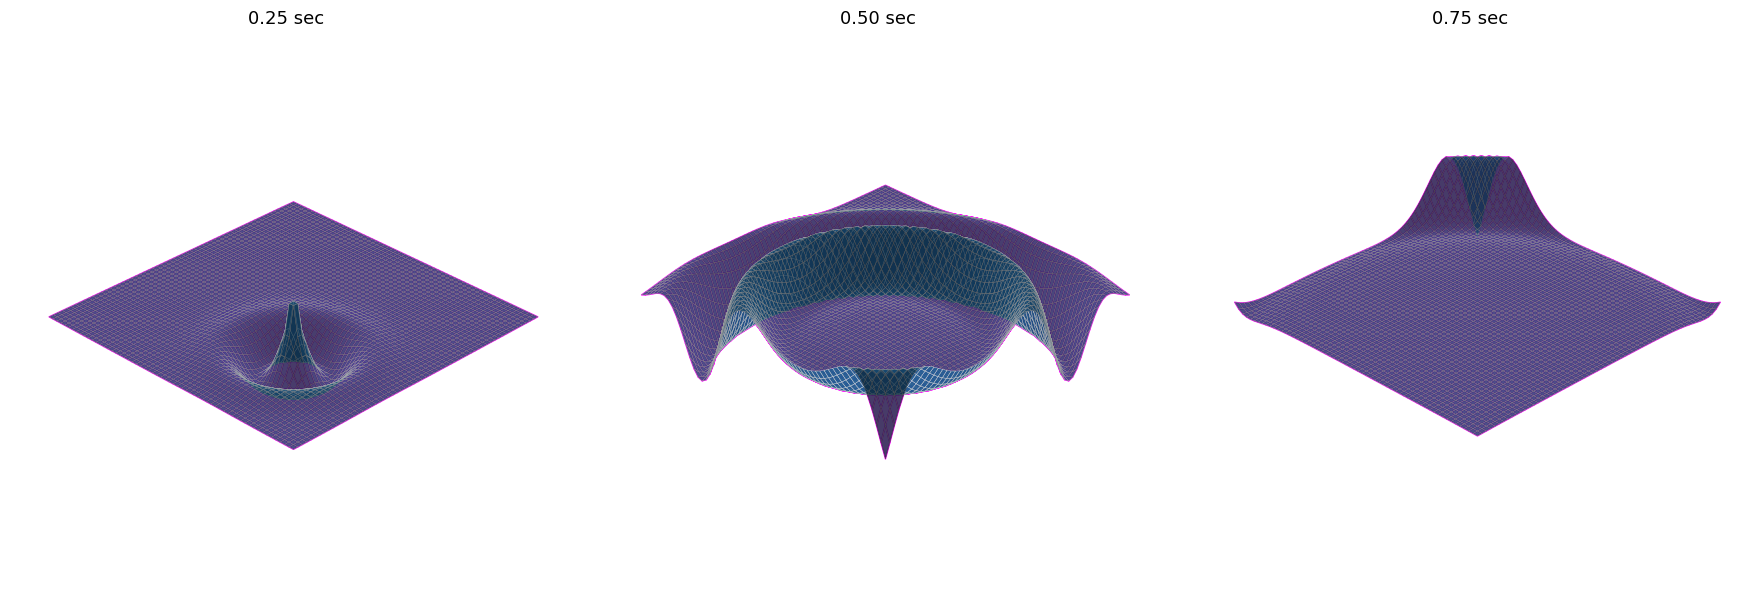

In [6]:
from matplotlib import cm

snap_titles = ['0.25 sec', '0.50 sec', '0.75 sec']

# Physical-domain coordinate grids [m]
x_coord = np.arange(shape[0]) * spacing[0]
z_coord = np.arange(shape[1]) * spacing[1]
X, Z = np.meshgrid(x_coord, z_coord, indexing='ij')

color_data = model.mu.data[nbl:-nbl, nbl:-nbl]
norm = plt.Normalize(color_data.min(), color_data.max())
colors = cm.spring(norm(color_data))

fig = plt.figure(figsize=(18, 6), facecolor='white')

for n, (data, title) in enumerate(zip(snapshots, snap_titles)):
    ax = fig.add_subplot(1, 3, n + 1, projection='3d')

    # Normalise per-frame so the wavefront is visible at each time
    vmax = np.max(np.abs(data))
    if vmax > 0:
        data = -data / vmax

    ax.plot_surface(
        X, Z, data* 3e2,
        rstride=1, cstride=1,
        linewidth=1,
        alpha=0.5,
        facecolors=colors, shade=False,
        # edgecolors='r',
    )
    ax.plot_surface(
        X, Z, data* 3e2,
        rstride=1, cstride=1,
        linewidth=0.3, edgecolors='w',
        # color='white',
        alpha=0.75
        # shade=False,
    )
    ax.set_title(title, fontsize=13, pad=8)
    ax.view_init(elev=30, azim=225)
    ax.set_axis_off()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

5.409999847412109
12.010899
(140, 60)


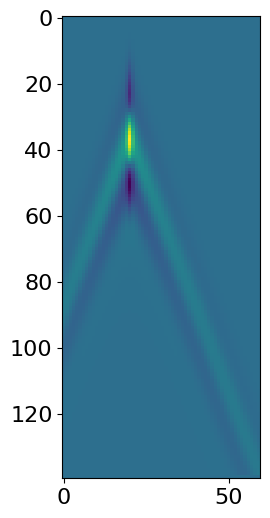

In [10]:
print(f"{model.critical_dt:.15f}")
print(np.linalg.norm(rec.data))
print(rec.data.shape)
np.save("sh_varying_rec.npy", rec.data)
plt.imshow(rec.data)
plt.show()

In [8]:
print(op)

/* Devito generated code for Operator `ForwardSH` */

#define _POSIX_C_SOURCE 200809L
#define START(S) struct timeval start_ ## S , end_ ## S ; gettimeofday(&start_ ## S , NULL);
#define STOP(S,T) gettimeofday(&end_ ## S, NULL); T->S += (double)(end_ ## S .tv_sec-start_ ## S.tv_sec)+(double)(end_ ## S .tv_usec-start_ ## S .tv_usec)/1000000;
#define SAFEINV(a, b) (((a) < 9.999999960041972e-13F || ((float)b) < 9.999999960041972e-13F) ? (0.0F) : ((1.0F) / (a)))

#include "stdlib.h"
#include "math.h"
#include "sys/time.h"
#include "xmmintrin.h"
#include "pmmintrin.h"

struct dataobj
{
  void *restrict data;
  int * size;
  unsigned long nbytes;
  unsigned long * npsize;
  unsigned long * dsize;
  int * hsize;
  int * hofs;
  int * oofs;
  void * dmap;
} ;

struct profiler
{
  double section0;
  double section1;
  double section2;
} ;


int ForwardSH(struct dataobj *restrict b_vec, struct dataobj *restrict damp_vec, struct dataobj *restrict mu_vec, struct dataobj *restrict rec_vec, struct d